# Fundamentos do Aprendizado de Máquina

## Aprendizado Baseado em Modelos

### Exemplo: Análise do nível de satisfação em função do PIB per capita.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

#Muda a fonte dos Plots para Arial
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 4)

#Baixa o conjunto de dados
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")

lifesat

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6
5,Portugal,32181.154537,5.4
6,Poland,32238.157259,6.1
7,Estonia,35638.421351,5.7
8,Spain,36215.447591,6.3
9,Slovenia,36547.738956,5.9


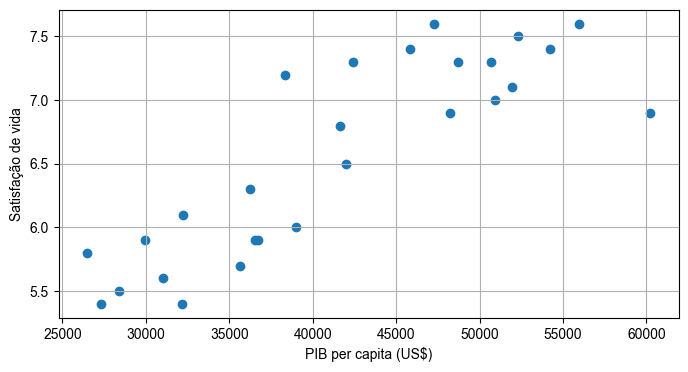

In [2]:
# Gráfico de dispersão
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

plt.scatter(X,y)
plt.grid()
plt.xlabel("PIB per capita (US$)")
plt.ylabel("Satisfação de vida")
plt.show()

min_pib = min(X)
max_pib = max(X)
min_life_sat = min(y)
max_life_sat = max(y)

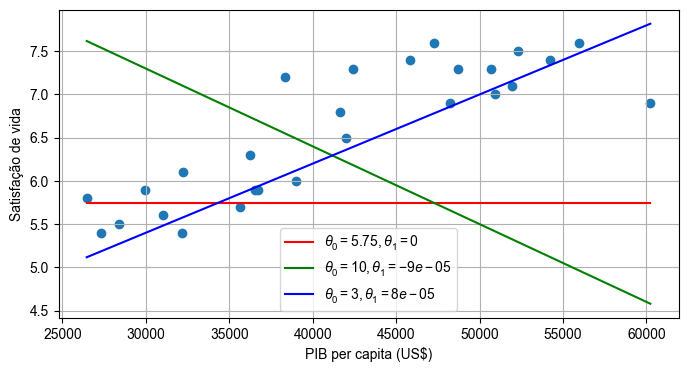

In [5]:
#Grafico de dispersão
plt.scatter(X,y)
plt.grid()
plt.xlabel("PIB per capita (US$)")
plt.ylabel("Satisfação de vida")

X_new = np.linspace(min_pib, max_pib, 1000)

# Modelo 1
Theta0, Theta1 = 5.75, 0
plt.plot(X_new, Theta0 + Theta1*X_new, "r", label=rf"$\theta_0 = {Theta0}, \theta_1 = {Theta1}$")

# Modelo 2
Theta0, Theta1 = 10, -9*1e-5
plt.plot(X_new, Theta0 + Theta1 * X_new, "g", label=rf"$\theta_0 = {Theta0}, \theta_1 = {Theta1}$")

# Modelo 3
Theta0, Theta1 = 3, 8*1e-5
plt.plot(X_new, Theta0 + Theta1 * X_new, "b", label=rf"$\theta_0 = {Theta0}, \theta_1 = {Theta1}$")

plt.legend()
plt.show()

In [6]:
model = LinearRegression()

model.fit(X, y)
t0 = model.intercept_
t1 = model.coef_

print(f"Intercept: {t0}")
print(f"Coefficients: {t1}")

Intercept: [3.74904943]
Coefficients: [[6.77889969e-05]]


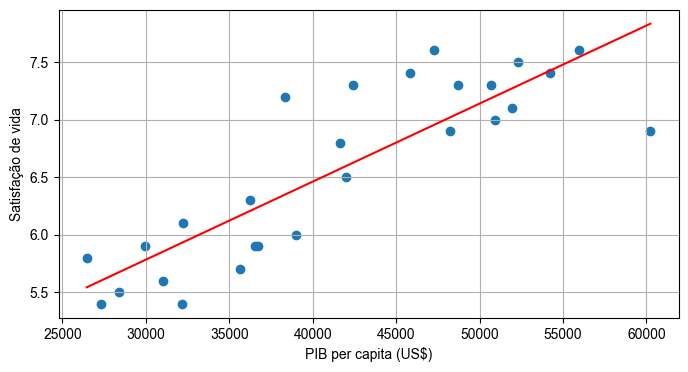

In [7]:
plt.scatter(X, y)
plt.grid(True)
plt.xlabel("PIB per capita (US$)")
plt.ylabel("Satisfação de vida")

# Criando a linha de regressão
X_input = np.linspace(min_pib, max_pib, 1000)

plt.plot(X_input, t0 + t1 * X_input, "r")

plt.show()

In [8]:
X_new = [[37_655.2]]
print(model.predict(X_new))

[[6.30165767]]


In [9]:
X_new = 37_655.2
y_prev = t0 + t1*X_new

print(y_prev)

[[6.30165767]]


## Dados de Treinamento não Representativos

### Exemplo: Incluindo novos paises para medir o nível de satisfação em função do PIB per capita.

In [11]:
full_country_stats = pd.read_csv("./datasets/lifesat/full_country_stats.csv")
full_country_stats.head()

,Country,GDP per capita (USD),Life satisfaction
0,South Africa,11466.189672,4.7
1,Colombia,13441.492952,6.3
2,Brazil,14063.982505,6.4
3,Mexico,17887.750736,6.5
4,Chile,23324.524751,6.5


In [13]:
X_full = full_country_stats[["GDP per capita (USD)"]].values
y_full = full_country_stats[["Life satisfaction"]].values

min_pib_full = min(X_full)
max_pib_full = max(X_full)
min_life_sat_full = min(y_full)
max_life_sat_full = max(y_full)

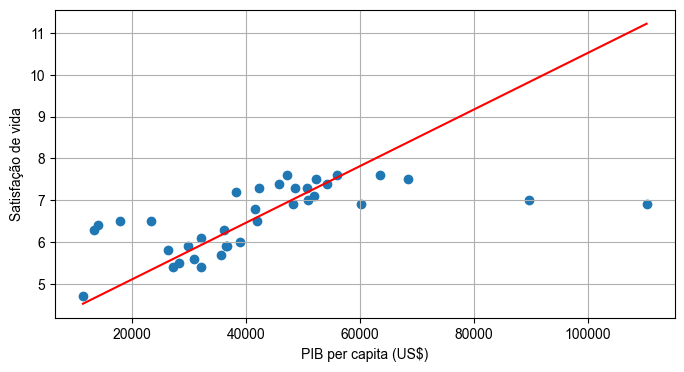

In [14]:
plt.scatter(X_full,y_full)
plt.grid()
plt.xlabel("PIB per capita (US$)")
plt.ylabel("Satisfação de vida")

# Criando a linha de regressão
X_input = np.linspace(min_pib_full, max_pib_full, 1000)

# Plota a curva de regressão com parte dos dados
plt.plot(X_input, t0 + t1 * X_input, "r")

plt.show()

In [15]:
model = LinearRegression()

model.fit(X_full, y_full)
t0_full = model.intercept_
t1_full = model.coef_

print(f"Intercept: {t0_full}")
print(f"Coefficients: {t1_full}")

Intercept: [5.5801896]
Coefficients: [[2.33408606e-05]]


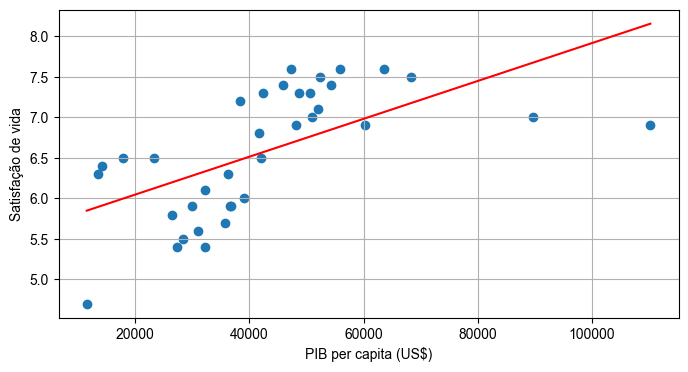

In [16]:
plt.scatter(X_full,y_full)
plt.grid()
plt.xlabel("PIB per capita (US$)")
plt.ylabel("Satisfação de vida")

# Criando a linha de regressão
X_input = np.linspace(min_pib_full, max_pib_full, 1000)

plt.plot(X_input, t0_full + t1_full * X_input, "r")

plt.show()

## Sobreajuste dos Dados de Treinamento

### Exemplo: Regressão polinomial para medir o nível de satisfação em função do PIB per capita.

In [17]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X_full)

model = LinearRegression()
model.fit(X_poly, y_full)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


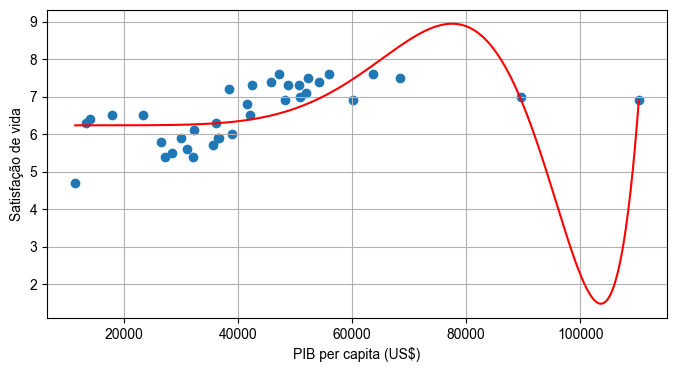

In [18]:
plt.scatter(X_full,y_full)
plt.grid()
plt.xlabel("PIB per capita (US$)")
plt.ylabel("Satisfação de vida")

# Criando a linha de regressão
X_input = np.linspace(min_pib_full, max_pib_full, 1000).reshape(-1, 1)

# Transformamos o input para o formato polinomial de grau 10
X_input_poly = poly.transform(X_input)

# Fazemos a previsão com os dados transformados
y_pred = model.predict(X_input_poly)

plt.plot(X_input, y_pred, "r")
plt.show()

In [20]:
from sklearn import linear_model

# Utiliza somente parte dos dados
ridge = linear_model.Ridge(alpha=10**9.5)
ridge.fit(X, y)

t0_ridge = ridge.intercept_[0]
t1_ridge = ridge.coef_.ravel()[0]

print(f"Intercept: {t0_ridge}")
print(f"Coefficients: {t1_ridge}")

Intercept: 5.347511088430103
Coefficients: 2.9331639732391384e-05


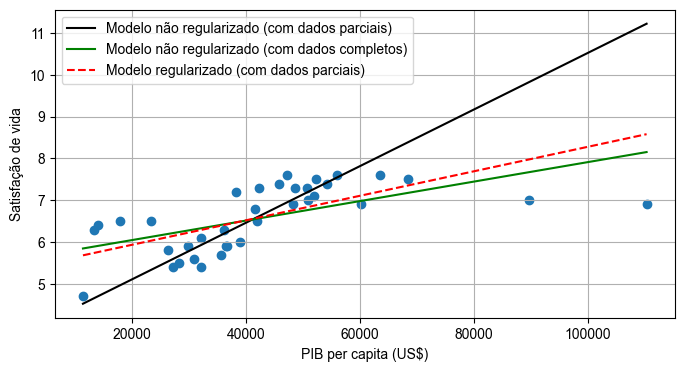

In [21]:
plt.scatter(X_full,y_full)
plt.grid()
plt.xlabel("PIB per capita (US$)")
plt.ylabel("Satisfação de vida")

# Criando a linha de regressão
X_input = np.linspace(min_pib_full, max_pib_full, 1000).reshape(-1, 1)

plt.plot(X_input, t0 + t1 * X_input, "k", label="Modelo não regularizado (com dados parciais)")
plt.plot(X_input, t0_full + t1_full * X_input, "g", label="Modelo não regularizado (com dados completos)")
plt.plot(X_input, t0_ridge + t1_ridge * X_input, "r--", label="Modelo regularizado (com dados parciais)")
plt.legend()
plt.show()